In [89]:
from utils import *

# Week 2

## Collect Enceladus seed cpds from literature

In [90]:
# read enceladus_seed_cpds
df = pd.read_csv('../enceladus_assets/enceladus_seed_cpds.csv')
df

,formula,compound_names,KEGG_ID,comment,source
0,H2O,H2O; Water,C00001,confirmed,Peter et al. 2023 nature astronomy; Detection...
1,CO2,CO2; Carbon dioxide,C00011,confirmed,Peter et al. 2023 nature astronomy; Detection...
2,CO,CO; Carbon monoxide,C00237,confirmed,Peter et al. 2023 nature astronomy; Detection...
3,CH4,Methane; CH4,C01438,confirmed,Peter et al. 2023 nature astronomy; Detection...
4,NH3,Ammonia; NH3,C00014,confirmed,Peter et al. 2023 nature astronomy; Detection...
...,...,...,...,...,...
171,0,Picolinic acid,C10164,0,Oba et al. 2023. nature communications; Uracil...
172,0,isonicotinic acid,C07446,0,Oba et al. 2023. nature communications; Uracil...
173,0,nicotinamide,C00153,0,Oba et al. 2023. nature communications; Uracil...
174,0,isonicotinamide,C02421,0,Oba et al. 2023. nature communications; Uracil...


In [91]:
enceladus_seed = set(df['KEGG_ID'])
enceladus_seed.remove('0')

In [92]:
# divide seeds by paper
papers = {}
papers['peter'] = df[df['source'].str.startswith('Peter')]
papers['parker'] = df[df['source'].str.startswith('Parker')]
papers['yoshimura'] = df[df['source'].str.startswith('Yoshimura')]
papers['takano'] = df[df['source'].str.startswith('Takano')]
papers['oba'] = df[df['source'].str.startswith('Oba')]

In [93]:
# drawMols(enceladus_seed)

In [94]:
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-24_11-10-36_no_lookahead_preExpansion_NONE_83276.pkl.gz')

In [95]:
seed80 = [c for c, i in result.cpds_folditer.items() if i == 0]

In [96]:
print(len(enceladus_seed), len(seed80))

106 80


In [97]:
aa_cids = set(["C00037",
    "C00041",
    "C00065",
    "C00188",
    "C00183",
    "C00407",
    "C00123",
    "C00148",
    "C00049",
    "C00025"])

seed70 = set(seed80) - aa_cids

In [98]:
# drawMols(seed70)

## Seed set comparison

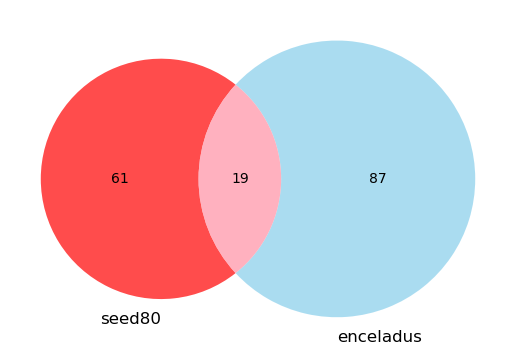

In [99]:
from matplotlib_venn import venn2

# Create a Venn diagram for 2 sets
venn2(subsets=[set(seed80), enceladus_seed], set_labels=('seed80', 'enceladus'),
      set_colors=('red', 'skyblue'), alpha=0.7)

# plt.savefig('venn_ToTAL.svg', dpi=300, bbox_inches='tight')
plt.show()

In [100]:
for c in set(seed80) & enceladus_seed:
    print(c, cpd2name[c])

C00160 Glycolate
C00407 L-Isoleucine
C00049 L-Aspartate
C00188 L-Threonine
C00383 Malonate
C00001 H2O
C00042 Succinate
C00149 (S)-Malate
C00022 Pyruvate
C00065 L-Serine
C00283 Hydrogen sulfide
C00282 Hydrogen
C00011 CO2
C00041 L-Alanine
C00123 L-Leucine
C00209 Oxalate
C00014 Ammonia
C00183 L-Valine
C00037 Glycine


In [101]:
# drawMols(seed70 - enceladus_seed)

## Run network expansion with Enceladus seed

In [102]:
# function to draw trajectory

def drawNE(fm):
    iter2cpds = {}
    for c, i in fm.scope.cpd_iteration_dict.items():
        if i not in iter2cpds.keys():
            iter2cpds[i] = [c]
        else:
            iter2cpds[i].append(c)
            
    iter2cpdsNum = {}
    for i in iter2cpds.keys():
        iter2cpdsNum[i] = len(iter2cpds[i])
        
    plt.figure(figsize=(30, 5))
    plt.plot(iter2cpdsNum.values(), color='k')
    
    plt.xlim([0, max(iter2cpdsNum.keys())])
    plt.ylim([0, max(iter2cpdsNum.values())+10])
    plt.xlabel('iteration', fontsize='18')
    plt.ylabel('# cpds discovered', fontsize='18')
    plt.xticks(fontsize='18')
    plt.yticks(fontsize='18')
    
    # plt.savefig('vanilla_iter_vs_cpds_10AA.svg', dpi=300, bbox_inches='tight')
    plt.show()

In [103]:
import networkExpansionPy.folds as nf
from collections import Counter
from pathlib import PurePath, Path

# seed = sys.argv[1]
# random.seed(seed)
asset_path = nf.asset_path

# for vanilla
METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.01May2023.pkl") # path to metabolism object pickle
RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

# for FOLD-GATED
ALGORITHM = "no_look_ahead_rules"
WRITE = True # write result to disk
WRITE_TMP = False # write after each iteration
CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
STR_TO_APPEND_TO_FNAME = None # if writing result, str to append to filename
ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

## Metabolism
metabolism = pd.read_pickle(METABOLISM_PATH)
# remove reactions that produce H2O2 before O2
H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
metabolism.network = metabolism.network[~condition]
assert 'R00017_v1' not in list(metabolism.network['rn'])

## FoldRules
rn2rules = pd.read_pickle(RN2RULES_PATH)
foldrules = nf.FoldRules.from_rn2rules(rn2rules)

## Modify seeds with AA and GATP_rns
aa_cids = set(["C00037",
    "C00041",
    "C00065",
    "C00188",
    "C00183",
    "C00407",
    "C00123",
    "C00148",
    "C00049",
    "C00025"])

GATP_rns = {'R00200_gATP_v1',
    'R00200_gATP_v2',
    'R00430_gGTP_v1',
    'R00430_gGTP_v2',
    'R01523_gATP_v1',
    'R04144_gATP_v1',
    'R04208_gATP',
    'R04463_gATP',
    'R04591_gATP_v1',
    'R06836_gATP',
    'R06974_gATP',
    'R06975_gATP_v1'}

# seed = nf.Params(
#     rns = set(metabolism.network["rn"]) - set(rn2rules) | GATP_rns,  # start with non-fold-gated reactions
#     cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])),
#     folds = set(['spontaneous'])
# )

## modified seed (seed70, enceladus_seed etc.)
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
    cpds = enceladus_seed,
    folds = set(['spontaneous'])
)

## Inititalize fold metabolism
fm_e0 = nf.FoldMetabolism(metabolism, foldrules, seed)

calculating scope...
...done.


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


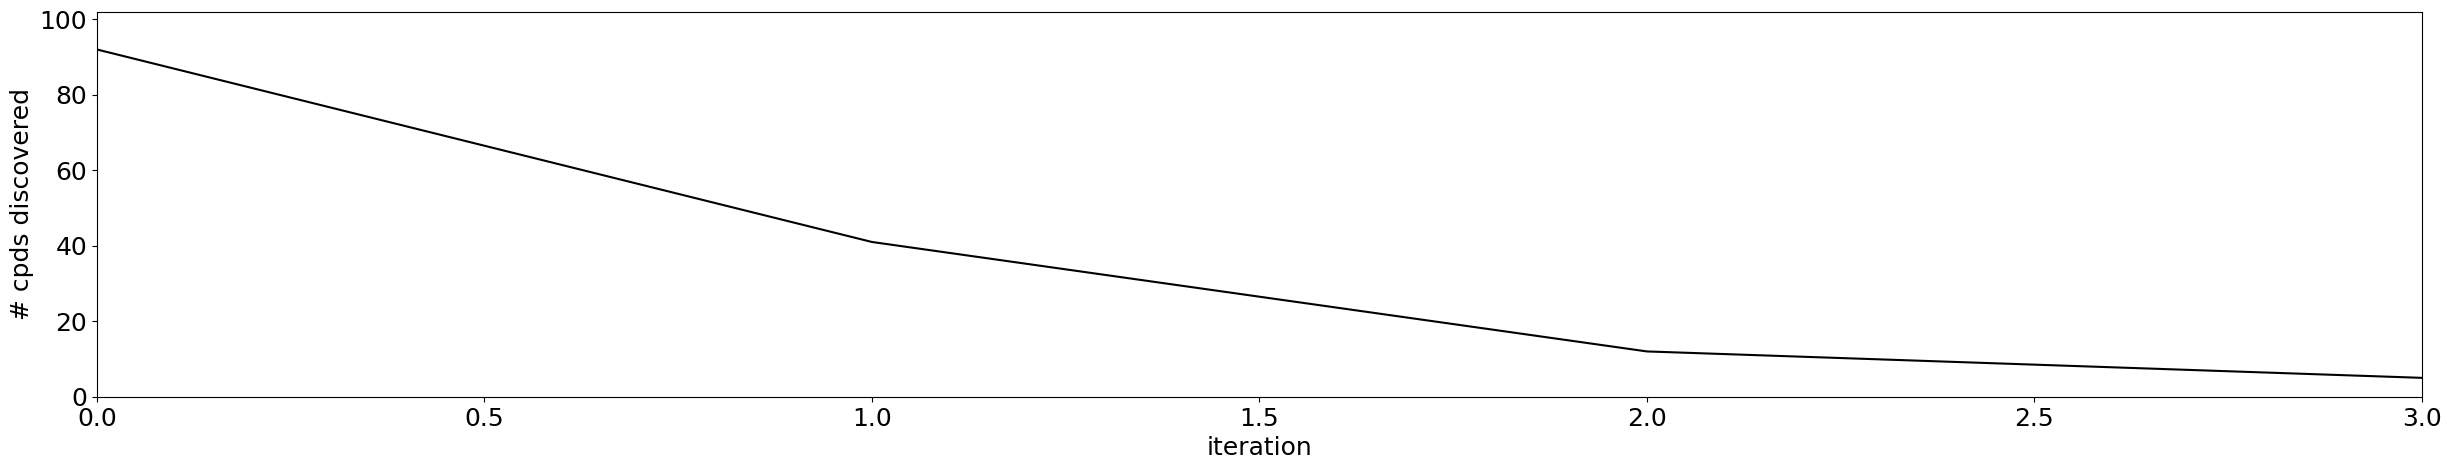

(106, 150)

In [107]:
# enceladus_seed
drawNE(fm_e0)
len(fm_e0.seed.cpds), len(fm_e0.scope.cpds)

### Add metals + generic cpds to enceladus_seed

In [158]:
# metals + generic cpds
metals = ['Z00020', 'Z00002', 'C00028', 'Z00030', 'Z00006', 'Z00015', 'C00050', 'Z00053', 'Z00055', 'Z00063', 'C17023', 'C00030', 'Z00069', 'Z00064', 'Z00001', 'Z00054', 'Z00060', 'Z00070', 'Z00029', 'Z00034', 'C22155', 'Z00067', 'Z00062', 'Z00033', 'C00023', 'C01330', 'C00071', 'C00034', 'C19609', 'C14819', 'C01335', 'C00069', 'C00305', 'C14818', 'C00070', 'C00175', 'C00038', 'C00238', 'C00080', 'C00150']
for m in metals:
    print(m, cpd2name[m])
print(len(metals))

Z00020 Generic FeS Cluster
Z00002 4Fe4S
C00028 Acceptor
Z00030 Mn
Z00006 Cobalt
Z00015 Iron
C00050 Metal
Z00053 Tungsten
Z00055 Calcium
Z00063 Generic FeS
C17023 Sulfur donor
C00030 Reduced acceptor
Z00069 Divalent Metal (M2)
Z00064 Molybdenum
Z00001 2Fe2S
Z00054 Zinc
Z00060 Monovalent Metal (M1)
Z00070 Copper
Z00029 Mg
Z00034 Nickel
C22155 [Fe-S] cluster scaffold protein
Z00067 3Fe4S
Z00062 Vanadium
Z00033 Sodium
C00023 Iron
C01330 Sodium cation
C00071 Aldehyde
C00034 Manganese
C19609 Nickel(2+)
C14819 Fe3+
C01335 ROH
C00069 Alcohol
C00305 Magnesium cation
C14818 Fe2+
C00070 Copper
C00175 Cobalt ion
C00038 Zinc cation
C00238 Potassium cation
C00080 H+
C00150 Molybdenum
40


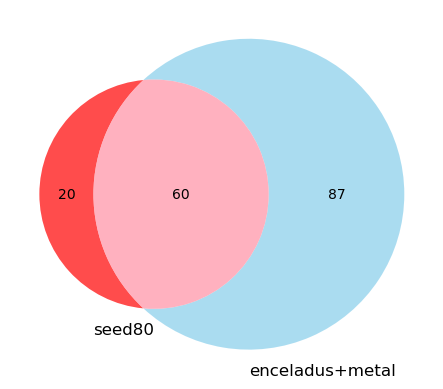

In [111]:
venn2(subsets=[set(seed80), (enceladus_seed | set(metals))], set_labels=('seed80', 'enceladus+metal'),
      set_colors=('red', 'skyblue'), alpha=0.7)

# plt.savefig('venn_ToTAL.svg', dpi=300, bbox_inches='tight')
plt.show()

### Re-run with Enceladus+metals

In [112]:
## modified seed (seed70, enceladus_seed etc.)
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
    cpds = enceladus_seed | set(metals),
    folds = set(['spontaneous'])
)

## Inititalize fold metabolism
fm_eM = nf.FoldMetabolism(metabolism, foldrules, seed)

calculating scope...
...done.


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


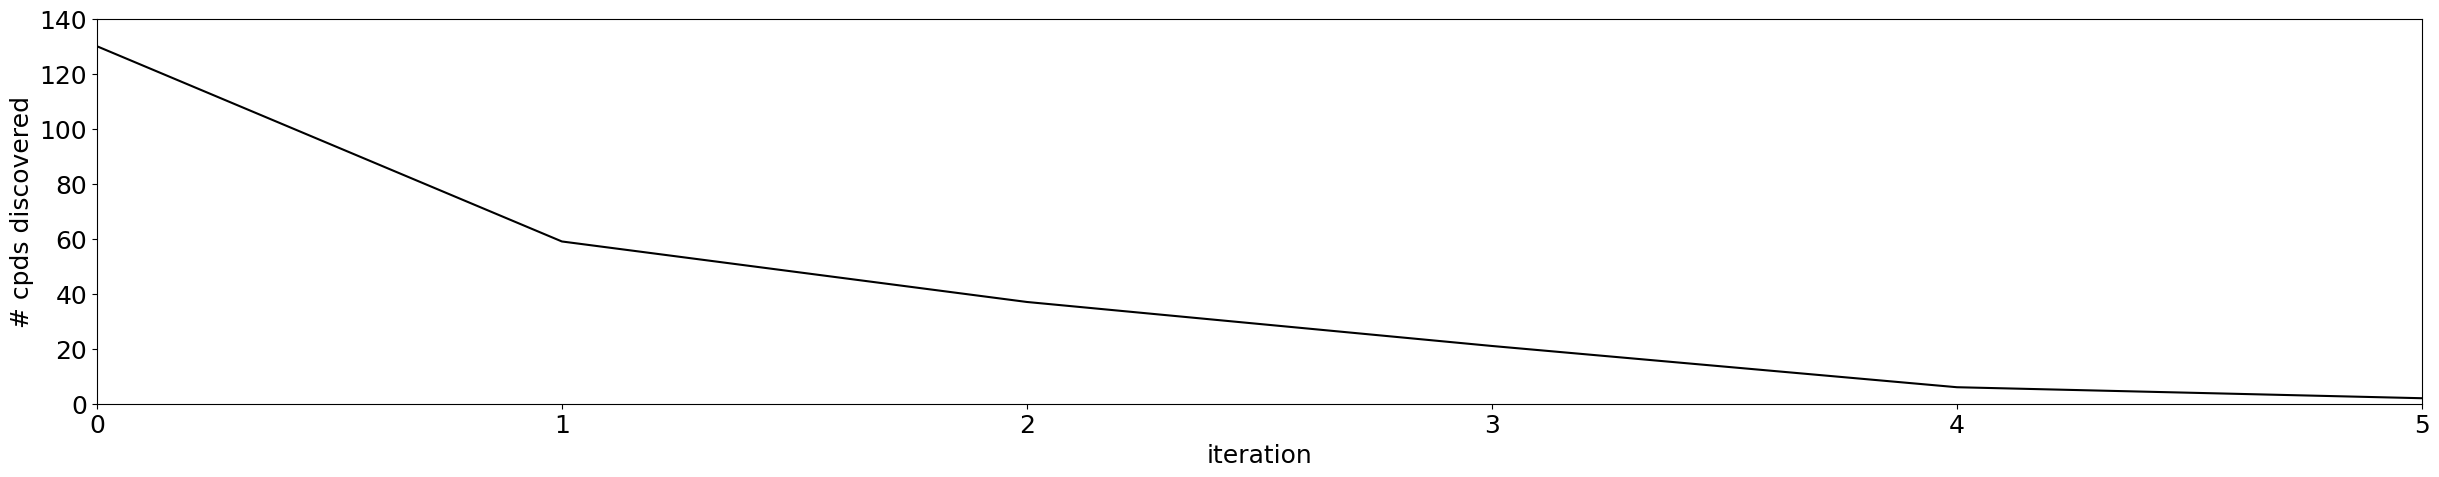

(147, 255)

In [113]:
# enceladus_seed + metals
drawNE(fm_eM)
len(fm_eM.seed.cpds), len(fm_eM.scope.cpds)

### Rescue with +1

In [116]:
rescue = set(seed70) - (enceladus_seed | set(metals))
print(len(rescue))
for c in rescue:
    print(c, cpd2name[c])

18
C01528 Hydrogen selenide
C00048 Glyoxylate
C00311 Isocitrate
C20679 Tungstate
C19806 Propane-1,2,3-tricarboxylate
C00122 Fumarate
C00026 2-Oxoglutarate
C00058 Formate
C00417 cis-Aconitate
C00288 HCO3-
C01127 4-Hydroxy-2-oxoglutarate
C00012 Peptide
C00033 Acetate
C00036 Oxaloacetate
C06232 Molybdate
C00161 2-Oxo acid
C01732 Mesaconate
C00009 Orthophosphate


In [28]:
# # add 1 seed at a time
# plusOne2ns = {}

# for plusOne in rescue:
    
#     ## FoldRules
#     rn2rules = pd.read_pickle(RN2RULES_PATH)
#     foldrules = nf.FoldRules.from_rn2rules(rn2rules)
    
#     seed = nf.Params(
#         rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#         cpds = enceladus_seed | set(metals) | set([plusOne]),
#         folds = set(['spontaneous'])
#     )
    
#     fm = nf.FoldMetabolism(metabolism, foldrules, seed)
#     print(len(fm.scope.cpds), plusOne, cpd2name[plusOne])
#     plusOne2ns[plusOne] = len(fm.scope.cpds)

In [29]:
# dict2csv(plusOne2ns, '../../plusOne2ns.csv')
plusOne2ns = csv2dict('../enceladus_assets/plusOne2ns.csv')

In [30]:
for key in plusOne2ns.keys():
    print(plusOne2ns[key], key, cpd2name[key])

255 C01732 Mesaconate
4260 C00009 Orthophosphate
255 C00048 Glyoxylate
259 C01528 Hydrogen selenide
255 C00036 Oxaloacetate
255 C00058 Formate
256 C20679 Tungstate
256 C19806 Propane-1,2,3-tricarboxylate
256 C06232 Molybdate
255 C00311 Isocitrate
255 C00417 cis-Aconitate
255 C00033 Acetate
276 C00026 2-Oxoglutarate
255 C01127 4-Hydroxy-2-oxoglutarate
259 C00012 Peptide
255 C00288 HCO3-
255 C00161 2-Oxo acid
255 C00122 Fumarate


### Enceladus + phosphate, no 'metals'

In [33]:
seed = nf.Params(
        rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = enceladus_seed | set(['C00009']),
        folds = set(['spontaneous'])
    )
    
## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm.scope.cpds))

calculating scope...
...done.
156


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


### Paper by paper

In [34]:
# paper2ns = {}

# for paper, cpds_df in papers.items():
#     s = set((cpds_df['KEGG_ID']))
#     s.remove('0')
    
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = s,
#             folds = set(['spontaneous'])
#         )
    
#     ## Inititalize fold metabolism
#     fm = nf.FoldMetabolism(metabolism, foldrules, seed)
#     print(len(s), len(fm.scope.cpds), paper)
#     paper2ns[paper] = len(fm.scope.cpds)

In [35]:
# dict2csv(paper2ns, '../../paper2ns.csv')
paper2ns = csv2dict('../enceladus_assets/paper2ns.csv')

## Summary Plot

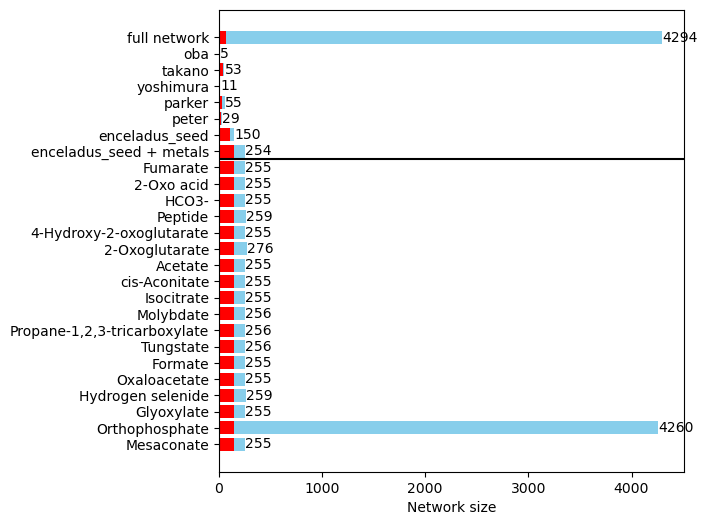

In [136]:
# Create a horizontal bar plot
plt.figure(figsize=(6, 6))

keys, values = [cpd2name[key] for key in plusOne2ns.keys()], list(plusOne2ns.values())
keys.append('enceladus_seed + metals')
values.append(254)
# keys.append('enceladus_seed + orthophosphate')
# values.append(156)
keys.append('enceladus_seed')
values.append(150)
keys.extend(paper2ns.keys())
values.extend(paper2ns.values())
keys.append('full network')
values.append(4294)

plt.barh(keys, values, color='skyblue')
for index, value in enumerate(values):
    plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black')

plt.axhline(y=17.5, color='k', linestyle='-')

# red for seed size
values = [145+1]*18
values.extend([145, 107, 22, 33, 10, 36, 7, 70])
plt.barh(keys, values, color='red')


plt.xlabel('Network size')
plt.show()

# Week 3-4

## Add more cpds to Enceladus_seed
These are also essential for WL pathway!

In [38]:
for c in ['C00009', 'C20679', 'C01528', 'C06232']:
    print(c, cpd2name[c])

metals.extend(['C00009', 'C20679', 'C01528', 'C06232'])
len(metals)

C00009 Orthophosphate
C20679 Tungstate
C01528 Hydrogen selenide
C06232 Molybdate


45

## 1) Is the Enceladus expansion trajectory significantly different from vanilla?
Calculate the Spearman rank corr. coef. of [vanilla+10AA vs. Enceladus] cpd discovery order 

In [39]:
print(len(enceladus_seed | set(metals)), len(seed80))

151 80


In [40]:
## enceladus
seed = nf.Params(
        rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
        cpds = enceladus_seed | set(metals),
        folds = set(['spontaneous'])
    )
    
## Inititalize fold metabolism
fm_e = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm_e.scope.cpds))

## vanilla + 10AA
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions
    cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) | aa_cids,
    folds = set(['spontaneous'])
)
    
## Inititalize fold metabolism
fm = nf.FoldMetabolism(metabolism, foldrules, seed)
print(len(fm.scope.cpds))

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
4312
calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.
4294


Spearman rank corr. = 0.8153312633866, p-value = 0.00E+00


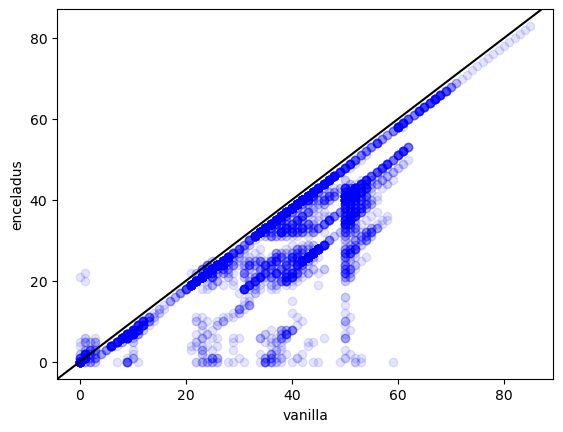

In [41]:
sp, p = spearman(fm.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict)
print(f'Spearman rank corr. = {sp}, p-value = {p}')
scatter(fm.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict, 'vanilla', 'enceladus')

### This has too many data points! Let's look at the level of KEGG pathways (modules).
For each KEGG metabolic module, record the "number of iterations until completion"

In [42]:
# function to check timing of pathway completion 
def pathwayCheck(fm, mods, output=True):
    mod2timing = {}
    iter2rn = {}
    mods_copy = copy.deepcopy(mods)
    
    for rn, i in fm.scope.rn_iteration_dict.items():
        if i not in iter2rn.keys():
            iter2rn[i] = [rn]
        else:
            iter2rn[i].append(rn)
    
    rn_list = []
    for i, rns in iter2rn.items():
        # keep updating rn_list
        rn_list.extend(rns)
        
        # for each mods module, check if all rns in module are in rn_list
        for m in mods_copy:
            if all(item in [item[:6] for item in rn_list] for item in module2rns[m]):
                if output:
                    print(f'{m}: {module2name[m]} is feasible at {i}')
                mod2timing[m] = i
                mods_copy.remove(m)
    return mod2timing

In [43]:
mod2t = pathwayCheck(fm, list(module2name.keys()), output=False)

In [44]:
mod2t_e = pathwayCheck(fm_e, list(module2name.keys()), output=False)

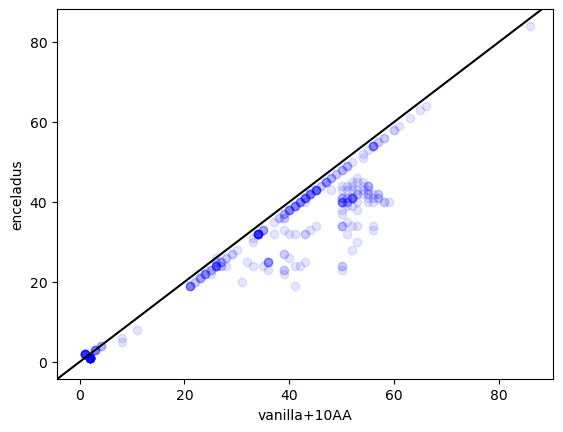

In [45]:
scatter(mod2t, mod2t_e, 'vanilla+10AA', 'enceladus')

In [46]:
# # bokeh plot:
# d1 = mod2t
# d2 = mod2t_e

# output_file("scatter.html")
# p = figure(width=800, height=800, title="iteration at module completion: vanilla+10AA vs. Enceladus")

# # Add annotations
# valid_keys, data1, data2 = todata(d1, d2)

# source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
# p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)

# # Add hover tool
# hover = HoverTool()
# hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
# p.add_tools(hover)

# # Customize plot
# p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
# p.xaxis.axis_label = 'vanilla+10AA'
# p.yaxis.axis_label = 'enceladus_seed'
# p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
# p.xgrid.grid_line_color = None

# # Show the plot
# show(p)

## 1b) Which compound is important for expansion? 
>i.e. Can we change the expansion speed by adding another compound to the enceladus_seed?

Add one cpd at a time (from ~4,000 cpds of full network) => check effect on expansion

In [47]:
# takes 3 hours for ~4,000 cpds

# cpd2effect = {}

# for plusOne in fm.scope.cpds - (set(enceladus_seed) | set(['C00009']) | set(metals)):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = set(enceladus_seed) | set(metals) | set([plusOne]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)
#     sp, p = spearman(fm_p.scope.cpd_iteration_dict, fm_e.scope.cpd_iteration_dict)
#     cpd2effect[plusOne] = sp

In [48]:
# dict2csv(cpd2effect, '../../cpd2effect_enceladus+1.csv')
cpd2effect = csv2dict('../enceladus_assets/cpd2effect_enceladus+1.csv')

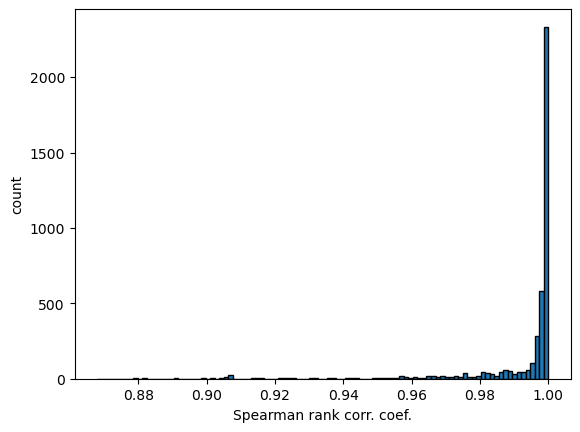

In [49]:
histogram(cpd2effect, bins=100, x_axis='Spearman rank corr. coef.',  y_axis='count')

print cpds with sp < 0.90

In [50]:
for c, sp in cpd2effect.items():
    if sp < 0.90:
        print(c, sp, cpd2name[c])

C00582 0.8985699987668111 Phenylacetyl-CoA
C00512 0.878682390594941 Benzoyl-CoA
C09809 0.8906859254125803 Cyclohexa-2,5-diene-1-carbonyl-CoA
C16162 0.888696103770576 (9Z,12Z,15Z)-Octadecatrienoyl-CoA
C00412 0.8791596005201124 Stearoyl-CoA
C02041 0.88205204333357 Eicosanoyl-CoA
C02050 0.8927481059648265 Linoleoyl-CoA
C01832 0.8839001285479148 Lauroyl-CoA
C06322 0.8814783043273383 Cyclohexa-1,5-diene-1-carbonyl-CoA
C06749 0.8906914645653614 6-Hydroxycyclohex-1-ene-1-carbonyl-CoA
C00154 0.8680495754812823 Palmitoyl-CoA
C09810 0.8906859254125803 Cyclohexa-1,4-diene-1-carbonyl-CoA
C20413 0.8989686747519507 3,5,7-Trioxododecanoyl-CoA
C02247 0.8787875076709908 Anthraniloyl-CoA
C21452 0.8788573578013597 (2-Aminobenzoyl)acetyl-CoA


In [51]:
# for sp < 0.9, draw scatterplot => identify major patterns
# they all look similar

# for c, sp in cpd2effect.items():
#     if sp < 0.90:
#         print(c, sp, cpd2name[c])

#         # run network expansion again with plusOne
#         seed = nf.Params(
#         rns = set(metabolism.network["rn"]) | GATP_rns, 
#         cpds = set(enceladus_seed) | set(metals) | set([c]),
#         folds = set(['spontaneous']))
        
#         fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)

#         # get module discovery timing
#         mod2t_p = pathwayCheck(fm_p, list(module2name.keys()))

#         # draw scatterplot
#         scatter(mod2t_e, mod2t_p, 'enceladus', 'enceladus +1')

In [52]:
# # bokeh for +C00154

# # run network expansion again
# c = 'C00154'
# seed = nf.Params(
# rns = set(metabolism.network["rn"]) | GATP_rns, 
# cpds = set(enceladus_seed) | set(metals) | set([c]),
# folds = set(['spontaneous']))
# fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)

# # get module discovery timing
# mod2t_p = pathwayCheck(fm_p, list(module2name.keys()), output=False)

# # bokeh plot:
# d1 = mod2t_e
# d2 = mod2t_p

# output_file(f"scatter_{c}.html")
# p = figure(width=800, height=800, title=f"iteration at module completion: Enceladus vs. Enceladus + {c}: {cpd2name[c]}")

# # Add annotations
# valid_keys, data1, data2 = todata(d1, d2)

# source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
# p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)

# # Add hover tool
# hover = HoverTool()
# hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
# p.add_tools(hover)

# # Customize plot
# p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
# p.xaxis.axis_label = 'enceladus_seed'
# p.yaxis.axis_label = f'enceladus_seed +{c}'
# p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
# p.xgrid.grid_line_color = None

# # Show the plot
# show(p)

relax threshold to .95

In [53]:
for c, sp in cpd2effect.items():
    if sp < 0.95:
        print(c, sp, cpd2name[c])

C20238 0.9061340790098172 (2R)-Ethylmalonyl-CoA
C06027 0.9074975441901053 L-erythro-3-Methylmalyl-CoA
C12092 0.9211809824986551 N-Methylanthraniloyl-CoA
C05117 0.9301313293685642 3-Aminobutanoyl-CoA
C00083 0.9061312785083321 Malonyl-CoA
C00683 0.9065642780020655 (S)-Methylmalonyl-CoA
C20968 0.9229875730058543 3-Hydroxy-3-(methylthio)propanoyl-CoA
C05338 0.9037127861006489 4-Hydroxyphenylacetyl-CoA
C03724 0.9067777327072769 S-(5-Hydroxy-2-furoyl)-CoA
C16327 0.9419742643271821 OPC8-CoA
C06028 0.9066092403865 2-Methylfumaryl-CoA
C22058 0.9409484595208706 Dihydroisopentenyldehydrorhodopin
C18054 0.9235326186610745 2-Amino-2-deoxyisochorismate
C00100 0.9064597783695042 Propanoyl-CoA
C02949 0.9067445532012144 4-Hydroxybenzoyl-CoA
C07118 0.9211623403010801 Benzoylacetyl-CoA
C00406 0.9145311902015737 Feruloyl-CoA
C07303 0.9145467398775149 4-Hydroxy-3-methoxyphenyl-beta-hydroxypropanoyl-CoA
C00136 0.9011247326951808 Butanoyl-CoA
C05195 0.9444378070100317 3-Hydroxybenzoyl-CoA
C00582 0.8985699987

In [54]:
check = ['C00016', 'C15672', 'C22349', 'C00101', 'C00251']
for c in check:
    print(c, cpd2name[c])

C00016 FAD
C15672 Heme O
C22349 Bacterioruberin
C00101 Tetrahydrofolate
C00251 Chorismate


In [55]:
# # bokeh for 5 compounds; takes time! => saved as html
# for c in check:
#     # run network expansion again
#     seed = nf.Params(
#     rns = set(metabolism.network["rn"]) | GATP_rns, 
#     cpds = set(enceladus_seed) | set(metals) | set([c]),
#     folds = set(['spontaneous']))
#     fm_p = nf.FoldMetabolism(metabolism, foldrules, seed)
    
#     # get module discovery timing
#     mod2t_p = pathwayCheck(fm_p, list(module2name.keys()), output=False)
    
#     # bokeh plot:
#     d1 = mod2t_e
#     d2 = mod2t_p
    
#     output_file(f"scatter_{c}.html")
#     p = figure(width=800, height=800, title=f"iteration at module completion: Enceladus vs. Enceladus + {c}: {cpd2name[c]}")
    
#     # Add annotations
#     valid_keys, data1, data2 = todata(d1, d2)
    
#     source = {'x': data1, 'y': data2, 'label': [key + ' ' + module2name[key] for key in valid_keys]}
#     p.scatter('x', 'y', source=source, size=10, color='blue', alpha=0.5)
    
#     # Add hover tool
#     hover = HoverTool()
#     hover.tooltips = [("", "@label"), ("x", "@x"), ("y", "@y")]
#     p.add_tools(hover)
    
#     # Customize plot
#     p.line([0, max(data1)], [0, max(data1)], line_width=2, color='black', alpha=0.7)
#     p.xaxis.axis_label = 'enceladus_seed'
#     p.yaxis.axis_label = f'enceladus_seed +{c}'
#     p.xaxis.ticker = [0, 20, 40, 60, 80]  # Convert range to list
#     p.xgrid.grid_line_color = None
    
#     # Show the plot
#     show(p)

## 2) Leave-One-Out analysis
If we remove one seed cpd at a time, which cpd will have the largest reduction in network size?

### with vanilla expansion

In [56]:
# cpd2loo_vanilla = {}

# for c in set((pd.read_csv(SEED_CPDS_PATH)["ID"])):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = set((pd.read_csv(SEED_CPDS_PATH)["ID"])) - set([c]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo_vanilla[c] = len(fm_loo.scope.cpds)

In [57]:
# dict2csv(cpd2loo_vanilla, '../../cpd2loo_vanilla.csv')
cpd2loo_vanilla = csv2dict('../enceladus_assets/cpd2loo_vanilla.csv')

In [58]:
for c, i in cpd2loo_vanilla.items():
    print(i, c, cpd2name[c])

4294 C00042 Succinate
431 Z00030 Mn
4271 C06232 Molybdate
4232 C00175 Cobalt ion
4294 Z00029 Mg
4294 C00071 Aldehyde
4294 C00122 Fumarate
4294 Z00053 Tungsten
4264 C00238 Potassium cation
4294 C00282 Hydrogen
4294 Z00001 2Fe2S
4294 Z00069 Divalent Metal (M2)
4265 C01528 Hydrogen selenide
4294 C01732 Mesaconate
4294 Z00006 Cobalt
394 C00026 2-Oxoglutarate
4293 C19806 Propane-1,2,3-tricarboxylate
4294 C00022 Pyruvate
4294 C22155 [Fe-S] cluster scaffold protein
4293 C00150 Molybdenum
4294 C00149 (S)-Malate
4294 Z00054 Zinc
4294 C00036 Oxaloacetate
1455 C00283 Hydrogen sulfide
4294 Z00067 3Fe4S
4294 Z00034 Nickel
135 C00009 Orthophosphate
4294 C00417 cis-Aconitate
4294 C00080 H+
4293 Z00062 Vanadium
4294 C00001 H2O
4294 C00033 Acetate
4294 C00058 Formate
4293 C00038 Zinc cation
4294 Z00063 Generic FeS
4294 C14819 Fe3+
4294 C00048 Glyoxylate
4294 C00050 Metal
4294 C00161 2-Oxo acid
4134 C00023 Iron
4294 C01127 4-Hydroxy-2-oxoglutarate
247 C00014 Ammonia
4294 Z00033 Sodium
4294 C00011 CO2
42

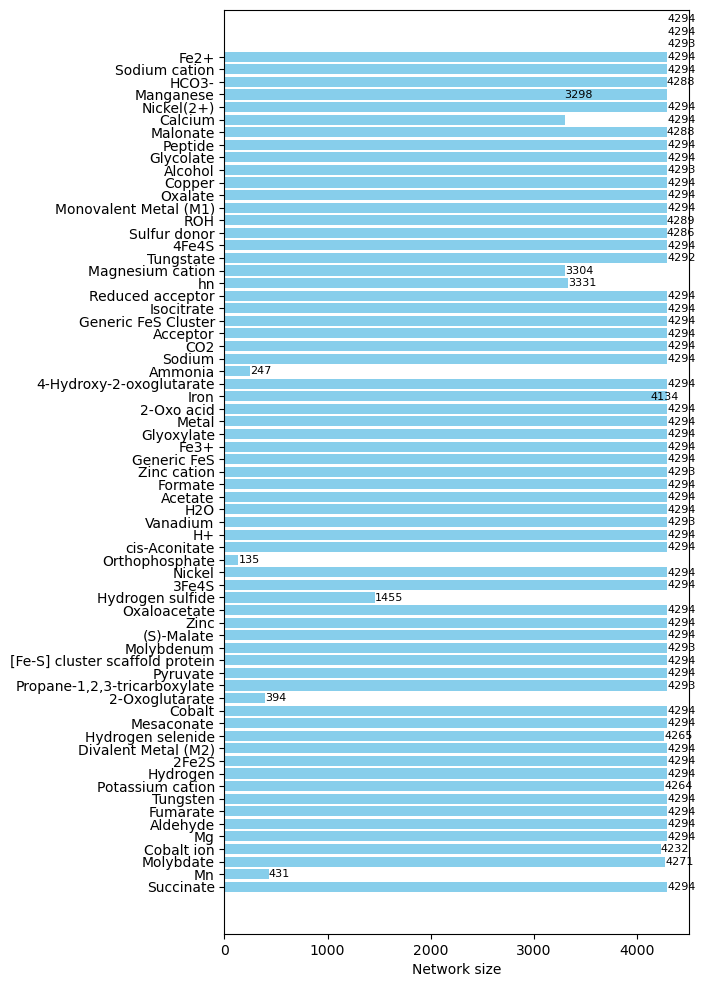

In [142]:
# Create a horizontal bar plot
plt.figure(figsize=(6, 12))

d = cpd2loo_vanilla

keys, values = [cpd2name[key] for key in d.keys()], list(d.values())

plt.barh(keys, values, color='skyblue')
for index, value in enumerate(values):
    plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black', fontsize=8)


plt.xlabel('Network size')
plt.show()

### with enceladus seedset

In [59]:
len(enceladus_seed | set(metals))

151

In [60]:
# cpd2loo = {}

# for c in enceladus_seed | set(metals):
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = (enceladus_seed | set(metals)) - set([c]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo[c] = len(fm_loo.scope.cpds)

In [61]:
# dict2csv(cpd2loo, '../../cpd2loo.csv')
cpd2loo = csv2dict('../enceladus_assets/cpd2loo.csv')

In [62]:
for c, i in cpd2loo.items():
    print(i, c, cpd2name[c])

4311 C07446 Isonicotinic acid
4312 C01950 Picolinamide
4312 C01799 D-Norvaline
4312 C06417 D-Valine
4312 Z00053 Tungsten
4311 C15521 Alkanesulfonate
4312 C05578 5,6-Dihydroxyindole
4293 C06232 Molybdate
4312 Z00001 2Fe2S
4312 Z00069 Divalent Metal (M2)
4312 Z00015 Iron
4312 C01432 Lactate
4312 C06104 Adipate
4312 C00022 Pyruvate
4312 C00149 (S)-Malate
4312 Z00034 Nickel
4312 C01020 6-Hydroxynicotinate
4312 C00711 Malate
4312 C00132 Methanol
4312 C00049 L-Aspartate
4311 Z00062 Vanadium
4312 C01845 Propan-2-ol
4312 C00320 Thiosulfate
4312 C00001 H2O
4312 C14818 Fe2+
4312 C02421 Isonicotineamide
4312 C00106 Uracil
4312 C05979 Propane-1-ol
4312 Z00063 Generic FeS
4312 C14819 Fe3+
4312 C02356 (S)-2-Aminobutanoate
4312 C00418 (R)-Mevalonate
4312 C00011 CO2
4312 C00587 3-Hydroxybenzoate
4312 C01089 (R)-3-Hydroxybutanoate
4312 C02378 6-Aminohexanoate
4312 C00153 Nicotinamide
4312 C00123 L-Leucine
4312 C10164 Picolinic acid
4312 C00030 Reduced acceptor
4281 C00305 Magnesium cation
4312 C02614 (

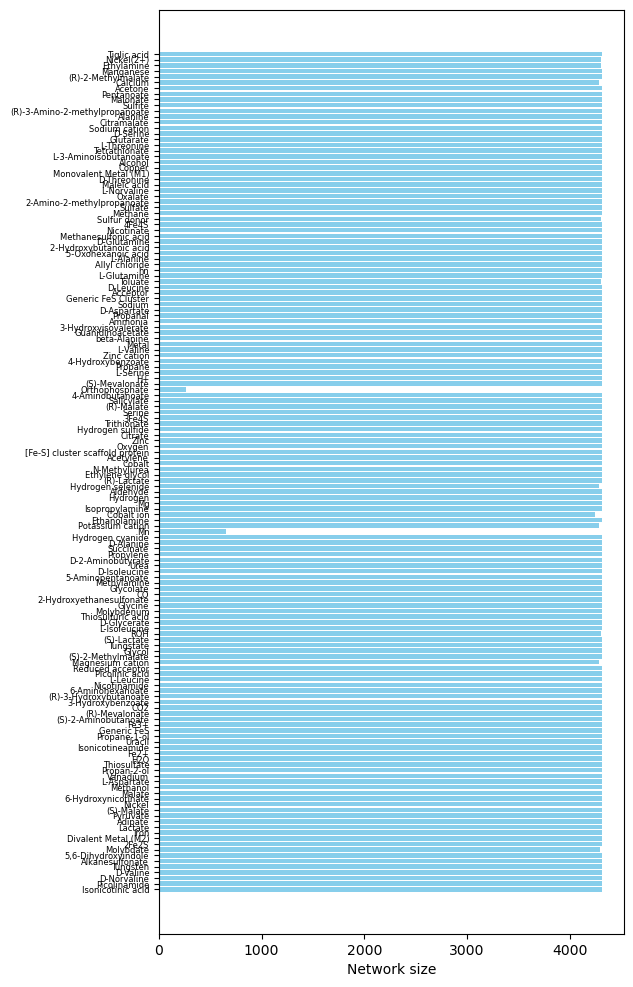

In [147]:
# Create a horizontal bar plot
plt.figure(figsize=(6, 12))

d = cpd2loo

keys, values = [cpd2name[key] for key in d.keys()], list(d.values())

plt.barh(keys, values, color='skyblue')
# for index, value in enumerate(values):
#     plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black', fontsize=8)
plt.yticks(fontsize=6)

plt.xlabel('Network size')
plt.show()

### Leave one-group out
enceladus_seed set is robust to perturbation... let's remove groups of cpds

In [63]:
for paper in papers:
    s = set(papers[paper]['KEGG_ID'])
    s.remove('0')
    print(paper, s)

peter {'C05979', 'C00001', 'C01380', 'C01548', 'C01438', 'C01845', 'C00207', 'C00189', 'C00479', 'C19316', 'C00283', 'C11505', 'C00237', 'C00282', 'C00007', 'C00011', 'C20783', 'C00218', 'C00132', 'C00014', 'C01326', 'C15588'}
parker {'C00407', 'C00820', 'C00716', 'C00402', 'C00049', 'C00188', 'C03284', 'C00099', 'C00740', 'C02356', 'C00797', 'C02378', 'C00431', 'C01826', 'C00065', 'C01401', 'C01570', 'C01205', 'C00819', 'C06418', 'C06748', 'C00041', 'C00218', 'C02261', 'C00064', 'C00123', 'C03665', 'C06417', 'C00334', 'C00133', 'C01799', 'C00183', 'C00037'}
yoshimura {'C00283', 'C00059', 'C05529', 'C15521', 'C00094', 'C01861', 'C11145', 'C05123', 'C02084', 'C00320'}
takano {'C00160', 'C08279', 'C16363', 'C00383', 'C00158', 'C00711', 'C00042', 'C00803', 'C00805', 'C05578', 'C00149', 'C00086', 'C06104', 'C00256', 'C00258', 'C00022', 'C01432', 'C02104', 'C02614', 'C05984', 'C20827', 'C01454', 'C00489', 'C01020', 'C02612', 'C00815', 'C00156', 'C00587', 'C00209', 'C01384', 'C01089', 'C0212

In [64]:
# cpd2loo_paper = {}

# for paper in papers:
#     s = set(papers[paper]['KEGG_ID'])
#     s.remove('0')
    
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = (enceladus_seed | set(metals)) - s,
#             folds = set(['spontaneous'])
#         )
        
#     print(len((enceladus_seed | set(metals)) - s))
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     cpd2loo_paper[paper] = len(fm_loo.scope.cpds)

In [65]:
# dict2csv(cpd2loo_paper, '../../cpd2loo_paper.csv')
cpd2loo_paper = csv2dict('../enceladus_assets/cpd2loo_paper.csv')

In [66]:
cpd2loo_paper
# removing parker or yoshimura restricts expansion

{'peter': 4308, 'parker': 572, 'yoshimura': 2233, 'takano': 4304, 'oba': 4311}

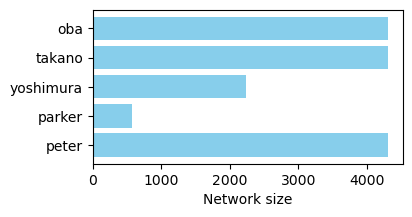

In [155]:
plt.figure(figsize=(4, 2))

d = cpd2loo_paper

keys, values = list(d.keys()), list(d.values())

plt.barh(keys, values, color='skyblue')
# for index, value in enumerate(values):
#     plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black', fontsize=8)
# plt.yticks(fontsize=6)

plt.xlabel('Network size')
plt.show()

### Which amino acid is important?
Let's remove all 'parker' amino acids => add back one AA at a time

In [67]:
parker = set(papers['parker']['KEGG_ID'])
parker.remove('0')

In [68]:
len((enceladus_seed | set(metals)))

151

In [69]:
len((enceladus_seed | set(metals)) - parker)

118

In [70]:
# plusOne2ns_AA = {}

# for AA in parker:
    
#     seed = nf.Params(
#             rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
#             cpds = ((enceladus_seed | set(metals)) - parker) | set([AA]),
#             folds = set(['spontaneous'])
#         )
        
#     fm_loo = nf.FoldMetabolism(metabolism, foldrules, seed)
#     print(len(fm_loo.seed.cpds))
#     plusOne2ns_AA[AA] = len(fm_loo.scope.cpds)

In [71]:
# dict2csv(plusOne2ns_AA, '../../plusOne2ns_AA.csv')
plusOne2ns_AA = csv2dict('../enceladus_assets/plusOne2ns_AA.csv')
plusOne2ns_AA.pop('0')

572

In [72]:
for c, ns in plusOne2ns_AA.items():
    print(ns, c, cpd2name[c])

572 C02261 D-2-Aminobutyrate
572 C00049 L-Aspartate
572 C00218 Methylamine
572 C01799 D-Norvaline
575 C00431 5-Aminopentanoate
572 C00820 D-Threonine
572 C06417 D-Valine
573 C01826 L-Norvaline
572 C01570 D-Leucine
573 C06748 Isopropylamine
572 C00740 D-Serine
576 C02378 6-Aminohexanoate
573 C00123 L-Leucine
574 C01205 (R)-3-Amino-2-methylpropanoate
572 C00065 L-Serine
572 C00402 D-Aspartate
572 C00188 L-Threonine
572 C00133 D-Alanine
4302 C00064 L-Glutamine
572 C00099 beta-Alanine
572 C06418 D-Isoleucine
574 C00407 L-Isoleucine
572 C00037 Glycine
573 C01401 Alanine
573 C00797 Ethylamine
572 C02356 (S)-2-Aminobutanoate
4302 C00334 4-Aminobutanoate
4302 C00819 D-Glutamine
572 C00041 L-Alanine
576 C00183 L-Valine
573 C00716 Serine
577 C03284 L-3-Aminoisobutanoate
572 C03665 2-Amino-2-methylpropanoate


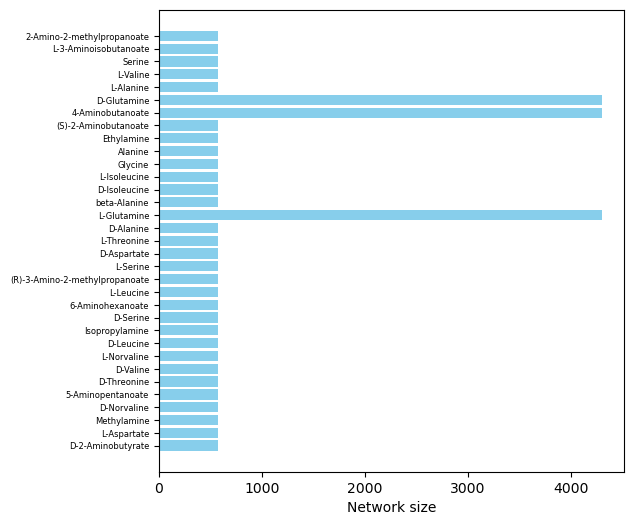

In [157]:
plt.figure(figsize=(6, 6))

d = plusOne2ns_AA

keys, values = [cpd2name[key] for key in d.keys()], list(d.values())

plt.barh(keys, values, color='skyblue')
# for index, value in enumerate(values):
#     plt.text(value + 0.5, index, str(value), va='center', ha='left', color='black', fontsize=8)
plt.yticks(fontsize=6)

plt.xlabel('Network size')
plt.show()

### Summary: Which compounds are important?
- orthophosphate
- sulfur source
- Glutamine!

## 3) pH=9

In [73]:
asset_path = nf.asset_path

# for vanilla
METABOLISM_PATH = PurePath(asset_path, "metabolic_networks","metabolism.v8.02Sep2024_pH9.pkl") # path to metabolism object pickle
RN2RULES_PATH = PurePath(asset_path,"rn2fold","rn2rules.20230224.pkl") # path to rn2rules object pickle
SEED_CPDS_PATH = PurePath(asset_path, "compounds", "seeds.Goldford2022.csv") # path to seed compounds csv

# for FOLD-GATED
ALGORITHM = "no_look_ahead_rules"
WRITE = True # write result to disk
WRITE_TMP = False # write after each iteration
CUSTOM_WRITE_PATH = None # if writing result, custom path to write to
STR_TO_APPEND_TO_FNAME = None # if writing result, str to append to filename
ORDERED_OUTCOME = False # ignore random seed and always choose folds based on sort order
IGNORE_REACTION_VERSIONS = True # when maximizing for reactions, don't count versioned reactions

## Metabolism
metabolism = pd.read_pickle(METABOLISM_PATH)
# remove reactions that produce H2O2 before O2
H2O2_rns = ['R00017_v1', 'R03532_v1', 'R09507_v1', 'R09740_v1', 'R09741_v1', 'R11522', 'R12455', 'R12454']
condition = ((metabolism.network['rn'].isin(H2O2_rns)) & (metabolism.network['direction'] == 'reverse'))
metabolism.network = metabolism.network[~condition]
assert 'R00017_v1' not in list(metabolism.network['rn'])

## FoldRules
rn2rules = pd.read_pickle(RN2RULES_PATH)
foldrules = nf.FoldRules.from_rn2rules(rn2rules)

GATP_rns = {'R00200_gATP_v1',
    'R00200_gATP_v2',
    'R00430_gGTP_v1',
    'R00430_gGTP_v2',
    'R01523_gATP_v1',
    'R04144_gATP_v1',
    'R04208_gATP',
    'R04463_gATP',
    'R04591_gATP_v1',
    'R06836_gATP',
    'R06974_gATP',
    'R06975_gATP_v1'}

## modified seed (seed70, enceladus_seed etc.)
seed = nf.Params(
    rns = set(metabolism.network["rn"]) | GATP_rns,  # start with non-fold-gated reactions + GATP_rns
    cpds = enceladus_seed | set(metals),
    folds = set(['spontaneous'])
)

## Inititalize fold metabolism
fm_9 = nf.FoldMetabolism(metabolism, foldrules, seed)

calculating scope...


/Users/tseamuscorlett/Desktop/LongoLab/Fold_Gated/networkExpansion/networkExpansionPy/lib.py:556: SparseEfficiencyWarning: Comparing sparse matrices using == is inefficient, try using != instead.
  X,Y = netExp_trace(R,P,x0,b)


...done.


In [74]:
len(fm_9.scope.cpds), len(fm_e.scope.cpds)

(3994, 4312)

In [75]:
len(fm_e.scope.cpds) - len(fm_9.scope.cpds)

318

In [76]:
for c in fm_e.scope.cpds - fm_9.scope.cpds:
    print(fm_e.scope.cpd_iteration_dict[c], c, cpd2name.get(c, 'no name'))

44 C04525 Fecosterol
54 C18324 (2S)-Methylsuccinyl-CoA
41 C00486 Bilirubin
58 C05797 Pheophytin a
65 C06427 (9Z,12Z,15Z)-Octadecatrienoic acid
45 C15915 4,4-Dimethyl-5alpha-cholesta-8-en-3beta-ol
50 C06509 Adenosyl cobinamide phosphate
42 C19835 Camelliol C
52 C04373 Etiocholanolone
44 C05790 I-Urobilinogen
66 C14829 12,13-DHOME
58 C21072 Palmitoleoyl-CoA
50 C20840 (25S)-3-Oxocholest-4-en-26-oyl-CoA
52 C03917 Dihydrotestosterone
44 C03845 5alpha-Cholest-8-en-3beta-ol
46 C05773 Cobyrinate
50 C06408 Precorrin 8X
48 C06503 Hydrogenobyrinate a,c diamide
44 C05439 5alpha-Cholesta-7,24-dien-3beta-ol
42 C01902 Cycloartenol
48 C01802 Desmosterol
81 C16338 3-Oxo-OPC4-CoA
50 C21305 (25R)-26-Oxocholest-4-en-3-one
39 C16372 Cyanidin 3-glucoside 5-caffeoylglucoside
66 C20186 5S,8R-DiHODE
68 C01226 (9S,13S,15Z)-12-Oxophyto-10,15-dienoate
58 C21192 Epoxypheophorbide a
49 C16497 3-Dehydro-2-deoxyecdysone
42 C20187 Achilleol B
51 C03772 5beta-Androstane-3,17-dione
52 C04555 Dehydroepiandrosterone sulfa

## 4) takeaways? future plans?